# LLM-as-Annotator: Zero-Shot Classification of UNSC Speeches on Tigray

## Overview

This notebook uses the Claude API to classify each text unit in the corpus into predefined conflict framing categories. Unlike BERTopic (Notebook 02), which discovers topics in an unsupervised way, this approach applies a theory-driven classification scheme designed by the researcher.

The "LLM-as-annotator" method follows Tornberg (2025), who showed that LLMs outperform human expert coders and supervised classifiers at annotating political text. Validation against human coding is essential and is covered in Notebook 04.

## Framing Categories

Each text is classified into one or more of these frames:

1. **Humanitarian**: Focus on humanitarian crisis, aid access, civilian suffering, food insecurity, displacement.
2. **Security**: Focus on military operations, ceasefire, armed groups, territorial control, violence.
3. **Accountability**: Focus on human rights violations, investigations, war crimes, international law, justice.
4. **Sovereignty**: Focus on non-interference, internal affairs, national unity, territorial integrity, state consent.
5. **Political process**: Focus on negotiations, dialogue, mediation, AU peace process, elections, governance.

These categories are informed by the conflict framing literature and the patterns observed in the BERTopic analysis.

## Setup and Data Loading

In [1]:
import os
import json
import time
import pandas as pd
from anthropic import Anthropic
from dotenv import load_dotenv

# Set working directory
os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-text-analysis")

# Load API key from .env file
load_dotenv()
client = Anthropic()

# Verify connection
print("API client initialized successfully")

# Load corpus
df = pd.read_csv("data/processed/corpus.csv", parse_dates=["date"])
print(f"Corpus loaded: {len(df)} text units")

API client initialized successfully
Corpus loaded: 88 text units


## Step 1: Design the Classification Prompt

The prompt instructs Claude to classify each text into one or more framing categories. Key design choices:

- **Multiple labels allowed**: A single speech often combines humanitarian and security framing.
- **Confidence scores**: The model returns a score (0.0–1.0) for each category, enabling nuanced analysis.
- **Structured JSON output**: Ensures consistent, machine-readable responses.
- **Truncation**: Texts longer than 2000 words are truncated to control API costs while retaining enough content for accurate classification.

We use Claude Haiku for cost efficiency. Haiku is sufficient for classification tasks and costs roughly 10x less than Sonnet.

In [2]:
# Define the classification prompt

SYSTEM_PROMPT = """You are an expert political scientist specializing in conflict research and UN Security Council discourse. Your task is to classify texts from UNSC meetings on the Tigray conflict into framing categories.

For each text, assign a confidence score (0.0 to 1.0) for EACH of the following five frames:

1. HUMANITARIAN: Focus on humanitarian crisis, aid access, civilian suffering, food insecurity, displacement, public services, medical needs.
2. SECURITY: Focus on military operations, ceasefire, armed groups, territorial control, violence, weapons, airstrikes, troop movements.
3. ACCOUNTABILITY: Focus on human rights violations, investigations, war crimes, international humanitarian law, justice, sexual violence, atrocities.
4. SOVEREIGNTY: Focus on non-interference, internal affairs, national unity, territorial integrity, state consent, respect for sovereignty.
5. POLITICAL_PROCESS: Focus on negotiations, dialogue, mediation, AU peace process, elections, governance, political settlement, reconciliation.

Rules:
- A text can score high on multiple frames (they are not mutually exclusive).
- Use 0.0 for completely absent, 1.0 for dominant focus.
- Also identify the single PRIMARY frame (the one with highest score).
- Respond ONLY with valid JSON, no other text."""

def build_user_prompt(text, max_words=2000):
    """Build the user prompt with truncation for long texts."""
    words = text.split()
    if len(words) > max_words:
        text = " ".join(words[:max_words]) + " [TRUNCATED]"
    
    return f"""Classify this UNSC text on the Tigray conflict:

---
{text}
---

Respond with this exact JSON structure:
{{
    "humanitarian": 0.0,
    "security": 0.0,
    "accountability": 0.0,
    "sovereignty": 0.0,
    "political_process": 0.0,
    "primary_frame": "humanitarian"
}}"""

# Test on one document
test_text = df.iloc[0]["text"]
print(f"Test document: {df.iloc[0]['speaker_name']} ({df.iloc[0]['date'].date()})")
print(f"Word count: {df.iloc[0]['word_count']}")
print(f"\nFirst 200 chars of prompt text:")
print(test_text[:200])

Test document: Secretary-General (2021-02-02)
Word count: 178

First 200 chars of prompt text:
Secretary-General, Concerned about Situation in Ethiopia’s Tigray Region, Calls for Sustained, Impartial and Unimpeded Humanitarian Access
The following statement was issued today by the Spokesman for


In [3]:
# Test API call on a single document

def classify_text(client, text, max_retries=3):
    """Classify a single text using Claude Haiku."""
    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model="claude-haiku-4-5-20251001",
                max_tokens=300,
                system=SYSTEM_PROMPT,
                messages=[
                    {"role": "user", "content": build_user_prompt(text)}
                ]
            )
            # Parse the JSON response
            result = json.loads(response.content[0].text)
            return result
        except json.JSONDecodeError:
            print(f"  JSON parse error on attempt {attempt + 1}, retrying...")
            time.sleep(2)
        except Exception as e:
            print(f"  API error on attempt {attempt + 1}: {e}")
            time.sleep(5)
    
    # Return empty result if all retries fail
    return None

# Test on first document
test_result = classify_text(client, df.iloc[0]["text"])
print("=== TEST RESULT ===\n")
print(json.dumps(test_result, indent=2))

  JSON parse error on attempt 1, retrying...
  JSON parse error on attempt 2, retrying...
  JSON parse error on attempt 3, retrying...
=== TEST RESULT ===

null


In [4]:
# Debug: see the raw response

response = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=300,
    system=SYSTEM_PROMPT,
    messages=[
        {"role": "user", "content": build_user_prompt(df.iloc[0]["text"])}
    ]
)

print("Raw response:")
print(repr(response.content[0].text))

Raw response:
'```json\n{\n    "humanitarian": 0.95,\n    "security": 0.05,\n    "accountability": 0.0,\n    "sovereignty": 0.1,\n    "political_process": 0.0,\n    "primary_frame": "humanitarian"\n}\n```'


In [5]:
# Fixed classify function that strips markdown fences

def classify_text(client, text, max_retries=3):
    """Classify a single text using Claude Haiku."""
    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model="claude-haiku-4-5-20251001",
                max_tokens=300,
                system=SYSTEM_PROMPT,
                messages=[
                    {"role": "user", "content": build_user_prompt(text)}
                ]
            )
            # Strip markdown code fences if present
            raw = response.content[0].text.strip()
            raw = raw.replace("```json", "").replace("```", "").strip()
            
            result = json.loads(raw)
            return result
        except json.JSONDecodeError:
            print(f"  JSON parse error on attempt {attempt + 1}, retrying...")
            time.sleep(2)
        except Exception as e:
            print(f"  API error on attempt {attempt + 1}: {e}")
            time.sleep(5)
    
    return None

# Test again
test_result = classify_text(client, df.iloc[0]["text"])
print("=== TEST RESULT ===\n")
print(json.dumps(test_result, indent=2))

=== TEST RESULT ===

{
  "humanitarian": 0.95,
  "security": 0.05,
  "accountability": 0.0,
  "sovereignty": 0.1,
  "political_process": 0.05,
  "primary_frame": "humanitarian"
}


## Step 2: Classify the Full Corpus

We process all 88 text units with a 1-second delay between API calls to avoid rate limits. Estimated time: about 2 minutes. Estimated cost: under $0.20.

In [6]:
# Classify all documents

results = []

for i, row in df.iterrows():
    print(f"Processing {i+1}/{len(df)}: {row['speaker_name'][:25]:25s} ({row['date'].date()})...", end=" ")
    
    result = classify_text(client, row["text"])
    
    if result:
        result["text_id"] = row["text_id"]
        results.append(result)
        print(f"primary={result['primary_frame']}")
    else:
        print("FAILED")
    
    time.sleep(1)  # rate limit protection

print(f"\nCompleted: {len(results)}/{len(df)} documents classified")

Processing 1/88: Secretary-General         (2021-02-02)... primary=humanitarian
Processing 2/88: Eritrea                   (2021-04-16)... primary=sovereignty
Processing 3/88: Security Council          (2021-04-22)... primary=humanitarian
Processing 4/88: Eritrea                   (2021-05-27)... primary=sovereignty
Processing 5/88: Secretary-General         (2021-06-25)... primary=humanitarian
Processing 6/88: Secretary-General         (2021-06-26)... primary=accountability
Processing 7/88: Secretary-General         (2021-06-28)... primary=political_process
Processing 8/88: Mr. Amde                  (2021-07-02)... primary=sovereignty
Processing 9/88: The President             (2021-07-02)... primary=political_process
Processing 10/88: Ms. Juul                  (2021-07-02)... primary=humanitarian
Processing 11/88: Mr. Dang                  (2021-07-02)... primary=humanitarian
Processing 12/88: Mr. Nebenzia              (2021-07-02)... primary=sovereignty
Processing 13/88: Mr. Tirumur

In [7]:
# Merge LLM annotations into the corpus

df_results = pd.DataFrame(results)
df_annotated = df.merge(df_results, on="text_id")

# Summary of primary frames
print("=== PRIMARY FRAME DISTRIBUTION ===\n")
print(df_annotated["primary_frame"].value_counts())

print("\n=== AVERAGE FRAME SCORES ACROSS ALL DOCUMENTS ===\n")
frame_cols = ["humanitarian", "security", "accountability", "sovereignty", "political_process"]
print(df_annotated[frame_cols].mean().sort_values(ascending=False).round(3))

# Save annotated corpus
df_annotated.to_csv("data/processed/corpus_annotated.csv", index=False)
print("\nSaved to data/processed/corpus_annotated.csv")

=== PRIMARY FRAME DISTRIBUTION ===

primary_frame
humanitarian         53
political_process    16
sovereignty          11
security              4
accountability        3
none                  1
Name: count, dtype: int64

=== AVERAGE FRAME SCORES ACROSS ALL DOCUMENTS ===

humanitarian         0.660
security             0.479
political_process    0.452
accountability       0.342
sovereignty          0.317
dtype: float64

Saved to data/processed/corpus_annotated.csv


## Step 3: Visualize LLM Annotation Results

### 3a. Primary Frame by Country

The core question: do geopolitical blocs frame the Tigray conflict differently?

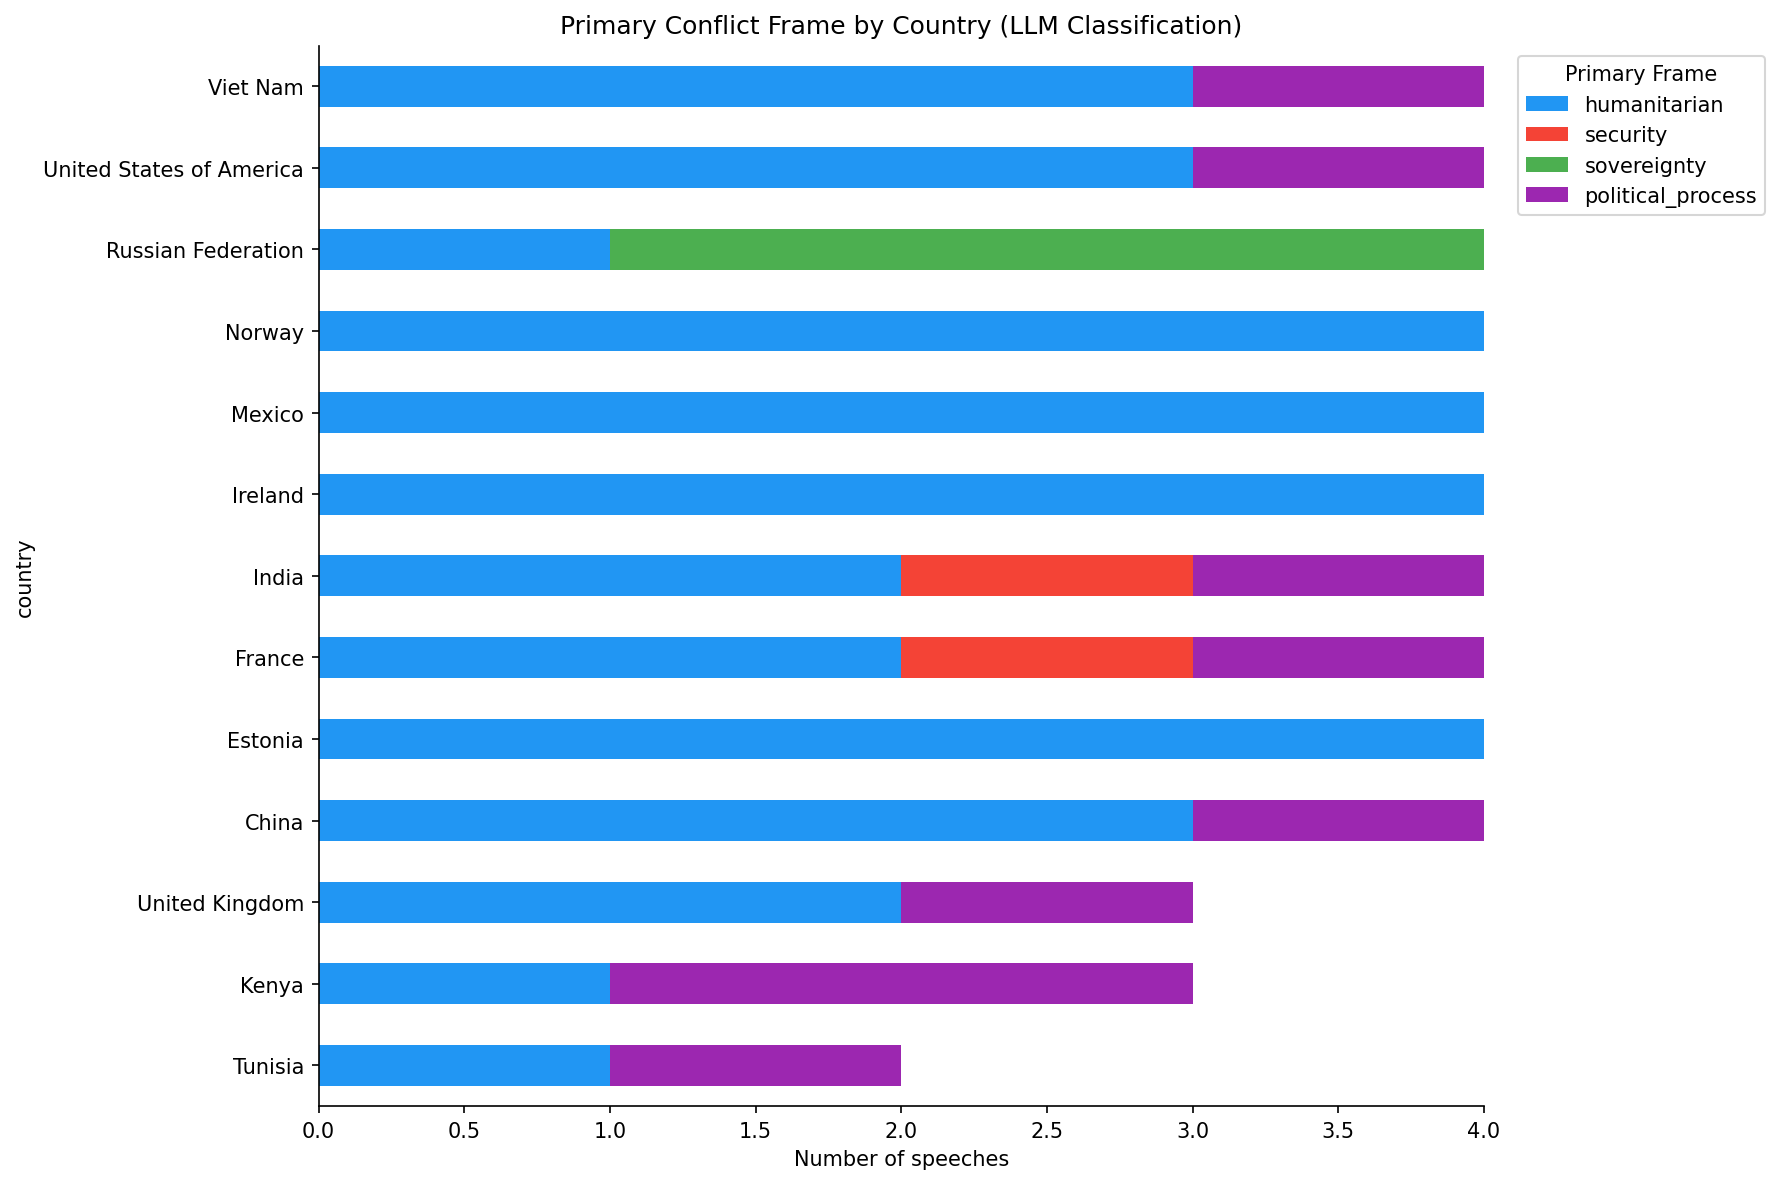

Saved to outputs/figures/primary_frame_by_country.png


In [8]:
# Primary frame by country (council members only)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

members = df_annotated[df_annotated["role"] == "council_member"]

ct = pd.crosstab(members["country"], members["primary_frame"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# Color map matching the frame categories
colors = {
    "humanitarian": "#2196F3",
    "security": "#F44336",
    "accountability": "#FF9800",
    "sovereignty": "#4CAF50",
    "political_process": "#9C27B0",
}

# Reorder columns
col_order = [c for c in ["humanitarian", "security", "accountability", 
             "sovereignty", "political_process"] if c in ct.columns]
ct = ct[col_order]

fig, ax = plt.subplots(figsize=(12, 8))
ct.plot(kind="barh", stacked=True, ax=ax, 
        color=[colors[c] for c in ct.columns])
ax.set_xlabel("Number of speeches")
ax.set_title("Primary Conflict Frame by Country (LLM Classification)")
ax.legend(title="Primary Frame", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/figures/primary_frame_by_country.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/primary_frame_by_country.png")

### 3b. Average Frame Scores by Country

Primary frame assignment loses nuance. The heatmap below shows average confidence scores across all five frames for each country, revealing secondary framing patterns that primary labels hide.

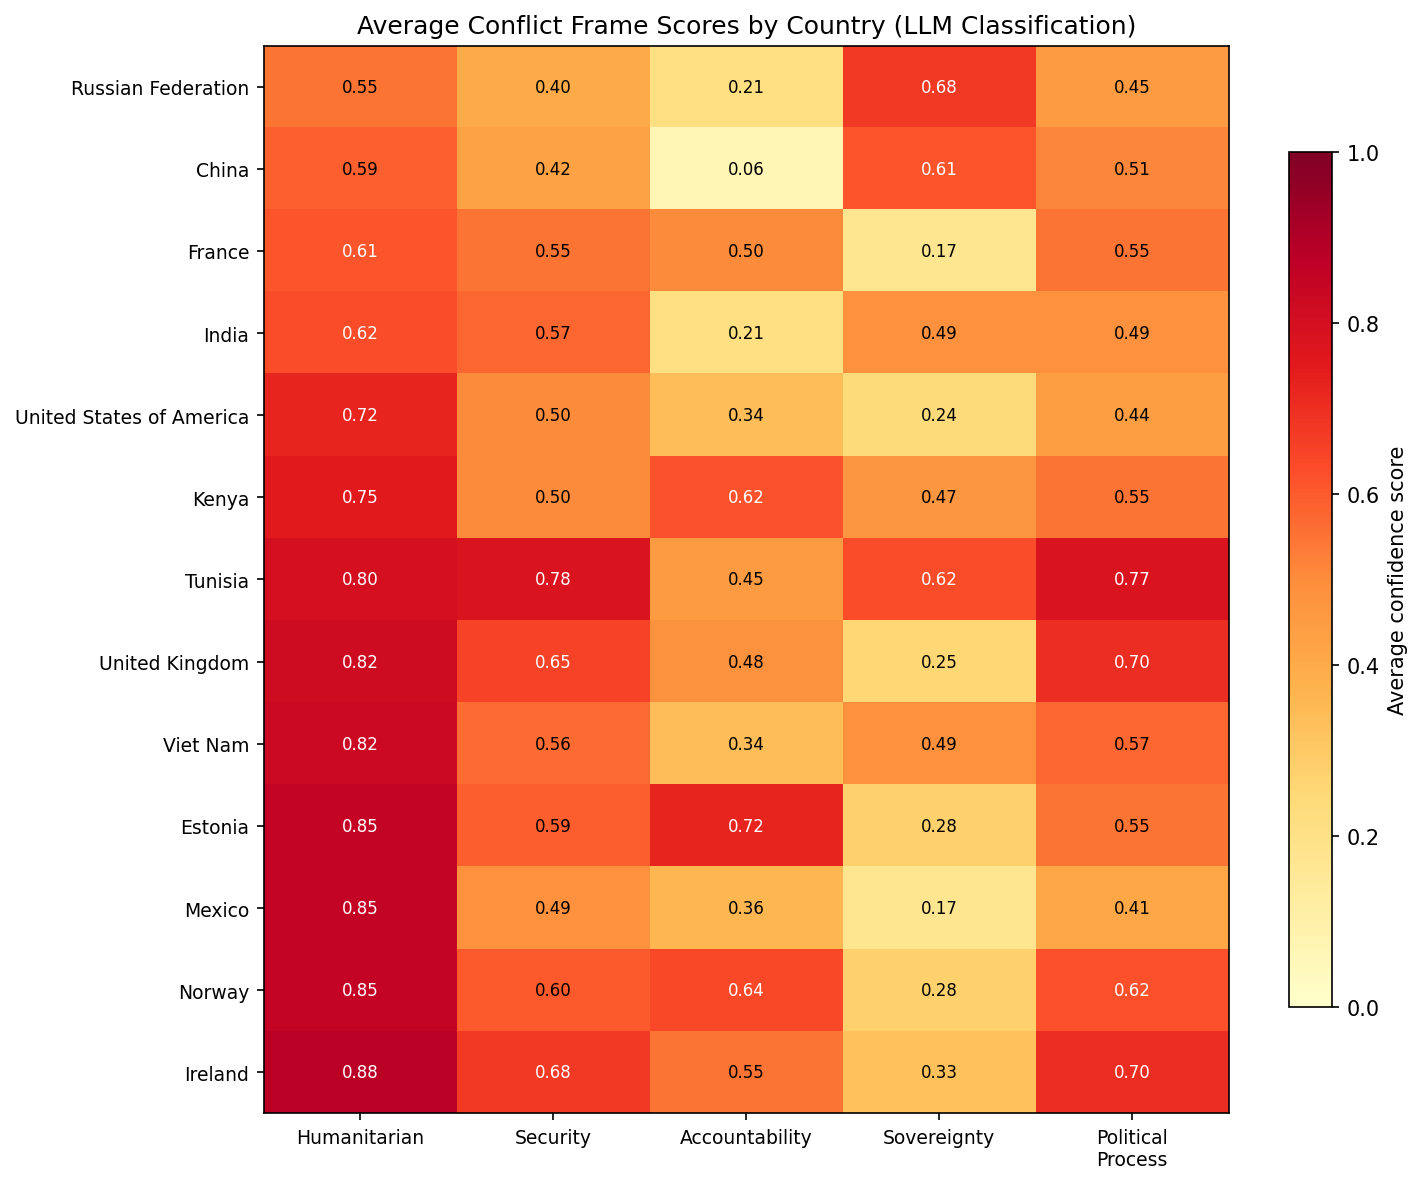

Saved to outputs/figures/frame_heatmap_by_country.png


In [9]:
# Heatmap of average frame scores by country (council members)
import numpy as np

members = df_annotated[df_annotated["role"] == "council_member"]
frame_cols = ["humanitarian", "security", "accountability", "sovereignty", "political_process"]

heatmap_data = members.groupby("country")[frame_cols].mean()
heatmap_data = heatmap_data.sort_values("humanitarian", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

# Labels
ax.set_xticks(range(len(frame_cols)))
ax.set_xticklabels(["Humanitarian", "Security", "Accountability", "Sovereignty", "Political\nProcess"], 
                     fontsize=9)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

# Add score values in each cell
for i in range(len(heatmap_data)):
    for j in range(len(frame_cols)):
        val = heatmap_data.values[i, j]
        color = "white" if val > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, label="Average confidence score", shrink=0.8)
ax.set_title("Average Conflict Frame Scores by Country (LLM Classification)")
plt.tight_layout()
plt.savefig("outputs/figures/frame_heatmap_by_country.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/frame_heatmap_by_country.png")